In [101]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, binom
from matplotlib import pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
import os

Loading the dataframe

In [102]:
shots=pd.read_csv(os.path.join("data","shots_all_seasons.csv"), low_memory=False)

shots.head()


,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Above the Break 3,Left Side Center,LC,24+ ft.,20.0,21.35,25,6,0,0
1,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,6,0,2
2,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Mid-Range,Left Side Center,LC,16-24 ft.,13.3,24.45,23,6,0,9
3,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Left Side,L,16-24 ft.,16.4,13.95,18,6,0,31
4,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Right Side,R,16-24 ft.,-15.8,7.85,16,6,0,55


In [103]:
shots.tail()

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
4450784,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.5,5.35,1,4,3,14
4450785,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Above the Break 3,Right Side Center,RC,24+ ft.,-18.3,31.95,32,4,2,53
4450786,2025,2024-25,1610612764,Washington Wizards,1642259,Alex Sarr,NaN,NaN,12-15-2024,22401217,...,Right Corner 3,Right Side,R,24+ ft.,-22.9,8.45,23,4,2,11
4450787,2025,2024-25,1610612764,Washington Wizards,1630551,Justin Champagnie,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,0.7,6.65,1,4,1,45
4450788,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.7,6.95,2,4,1,20


Plotting the court for visual examples

<Axes: >

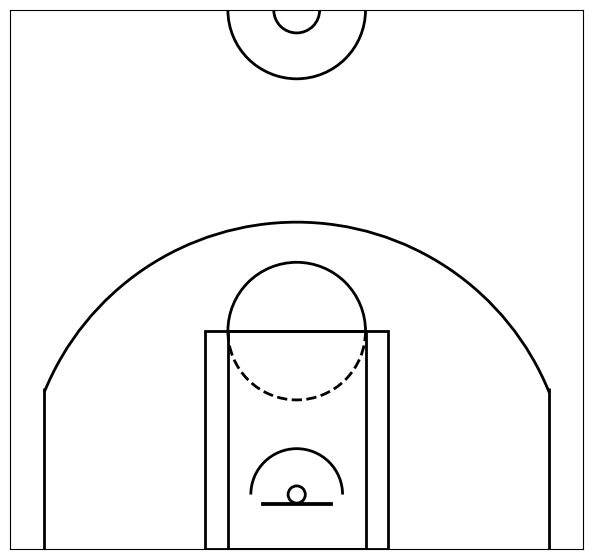

In [104]:

fig, ax = plt.subplots(figsize=(10, 7))
def draw_court(ax=None, color='black', lw=2, outer_lines=False, interval=20):
    if ax is None:
        ax = plt.gca()

    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                    bottom_free_throw, restricted, corner_three_a,
                    corner_three_b, three_arc, center_outer_arc,
                    center_inner_arc]

    if outer_lines:
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,color=color, fill=False)
        court_elements.append(outer_lines)

    for element in court_elements:
        ax.add_patch(element)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

draw_court(ax)

Analyzed season played by said player

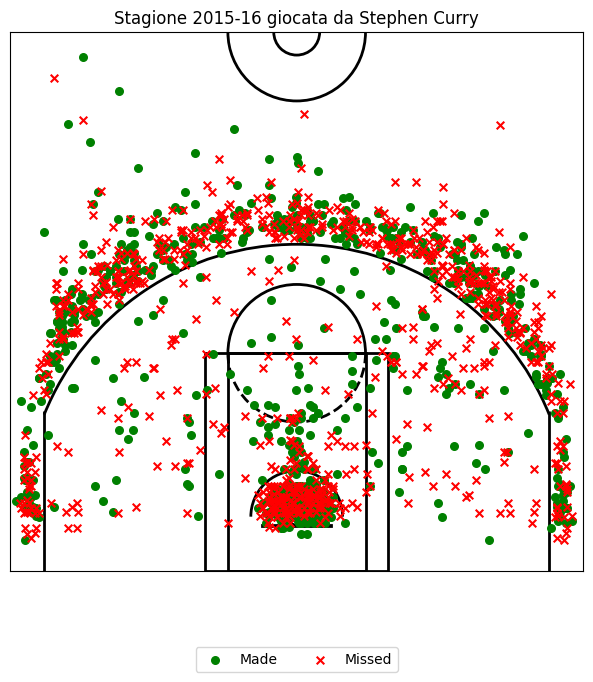

In [105]:
player = 'Stephen Curry'
season = 2016
shotsfiltered=shots[
    (shots['SEASON_1'] == season) & 
    (shots['PLAYER_NAME'] == player) &
    (shots['SHOT_DISTANCE'] >=0)
]

made_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == True]
missed_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == False]

completeseason = (shotsfiltered['SEASON_2']).iloc[0]

fig, ax = plt.subplots(figsize=(10, 7))

draw_court(ax)

offset=51.7

ax.scatter(made_shots['LOC_X'] * -10 , made_shots['LOC_Y'] * 10 - offset, 
                    color='green', label='Made', s=30)
ax.scatter(missed_shots['LOC_X'] * -10 , missed_shots['LOC_Y'] * 10 - offset, 
                    color='red', label='Missed', marker='x', s=30)


ax.set_title(f"Stagione {completeseason} giocata da {player}")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)


plt.show()

In [106]:
distanzefiltered = np.sqrt(shotsfiltered['LOC_X']**2 + shotsfiltered['LOC_Y']**2)

distanze=distanzefiltered[distanzefiltered<45] #shot before half court

mean = np.mean(distanze)
mode = stats.mode(np.round(distanze), keepdims=True).mode[0] 
varianza = np.var(distanze)
dev_std = np.std(distanze) 
min = np.min(distanze)
max = np.max(distanze)

Gaussian distribution comparison

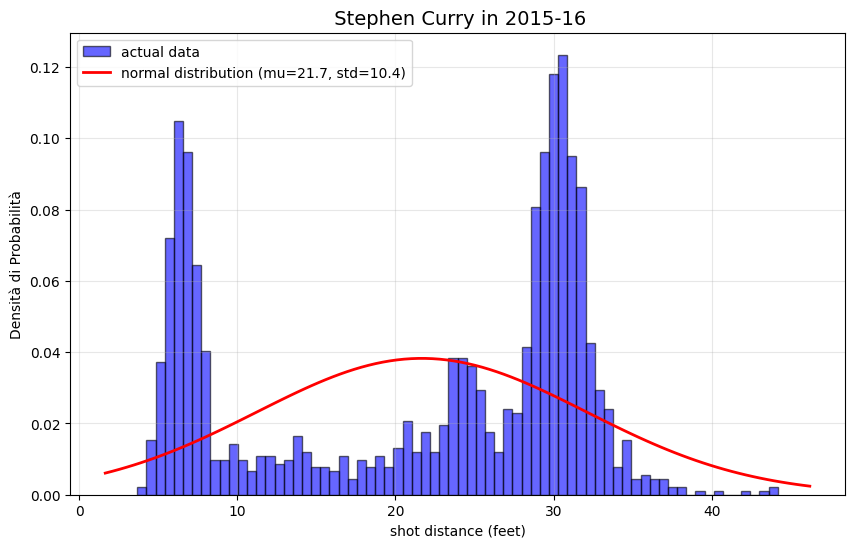

It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics


In [107]:
plt.figure(figsize=(10, 6))

plt.hist(distanze, bins=70, density=True, alpha=0.6, color='blue', edgecolor='black', label="actual data")

xmin, xmax = plt.xlim() #saving axes limits

#bell curve generation
x = np.linspace(xmin, xmax, 100) 
p = norm.pdf(x, mean, dev_std) 

plt.plot(x, p, 'r', linewidth=2, label=f'normal distribution (mu={mean:.1f}, std={dev_std:.1f})')

plt.title(f' {player} in {completeseason}', fontsize=14)
plt.xlabel('shot distance (feet)')
plt.ylabel('Densità di Probabilità')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
print("It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics" )

In [108]:
universe = shotsfiltered
ntotalshots = len(universe)

threeptshots = universe[universe['SHOT_TYPE'] == '3PT Field Goal']
threeptshots = len(threeptshots)
nshotsmade = len(shotsfiltered[shotsfiltered['SHOT_MADE'] == True])

twoptmade = len(universe[(universe['SHOT_TYPE'] == '2PT Field Goal') & (universe['SHOT_MADE'] == True)])
twoptmissed = len(universe[(universe['SHOT_TYPE'] == '2PT Field Goal') & (universe['SHOT_MADE'] == False)])
threeptmade = len(universe[(universe['SHOT_TYPE'] == '3PT Field Goal') & (universe['SHOT_MADE'] == True)])
threeptmissed = len(universe[(universe['SHOT_TYPE'] == '3PT Field Goal') & (universe['SHOT_MADE'] == False)])

labels = ['2PT Made', '2PT Missed', '3PT Made', '3PT Missed']
threeandtwoshots = [twoptmade, twoptmissed, threeptmade, threeptmissed]
prob3pt = threeptshots / ntotalshots #probability that the shot is from 3pt range 
prob3ptmade = threeptmade / threeptshots #probabilty of the shot to be made (from 3pt range)
probshotmade = nshotsmade / ntotalshots #probability that the shot will be made in general
probshotwas3 = (prob3ptmade * prob3pt) / probshotmade #probability that the shot was a three
verifica = threeptmade / nshotsmade

print(f"{prob3pt:.2%} probability that the shot is from 3pt range ")
print(f"{prob3ptmade:.2%} probabilty of the shot to be made (from 3pt range)")
print(f"{probshotmade:.2%} probability that the shot will be made in general")
print(f"(considering the made shot, there is a {probshotwas3:.1%} chance that said shot is a triple)")
print(f"actual verification with dataset files: {verifica:.2%}")

55.39% probability that the shot is from 3pt range 
45.36% probabilty of the shot to be made (from 3pt range)
50.38% probability that the shot will be made in general
(considering the made shot, there is a 49.9% chance that said shot is a triple)
actual verification with dataset files: 49.88%


Stephen Curry top 10 most used shot types:
['Jump Shot', 'Pullup Jump shot', 'Step Back Jump shot', 'Driving Layup Shot', 'Driving Finger Roll Layup Shot', 'Layup Shot', 'Floating Jump shot', 'Running Layup Shot', 'Cutting Layup Shot', 'Driving Reverse Layup Shot']



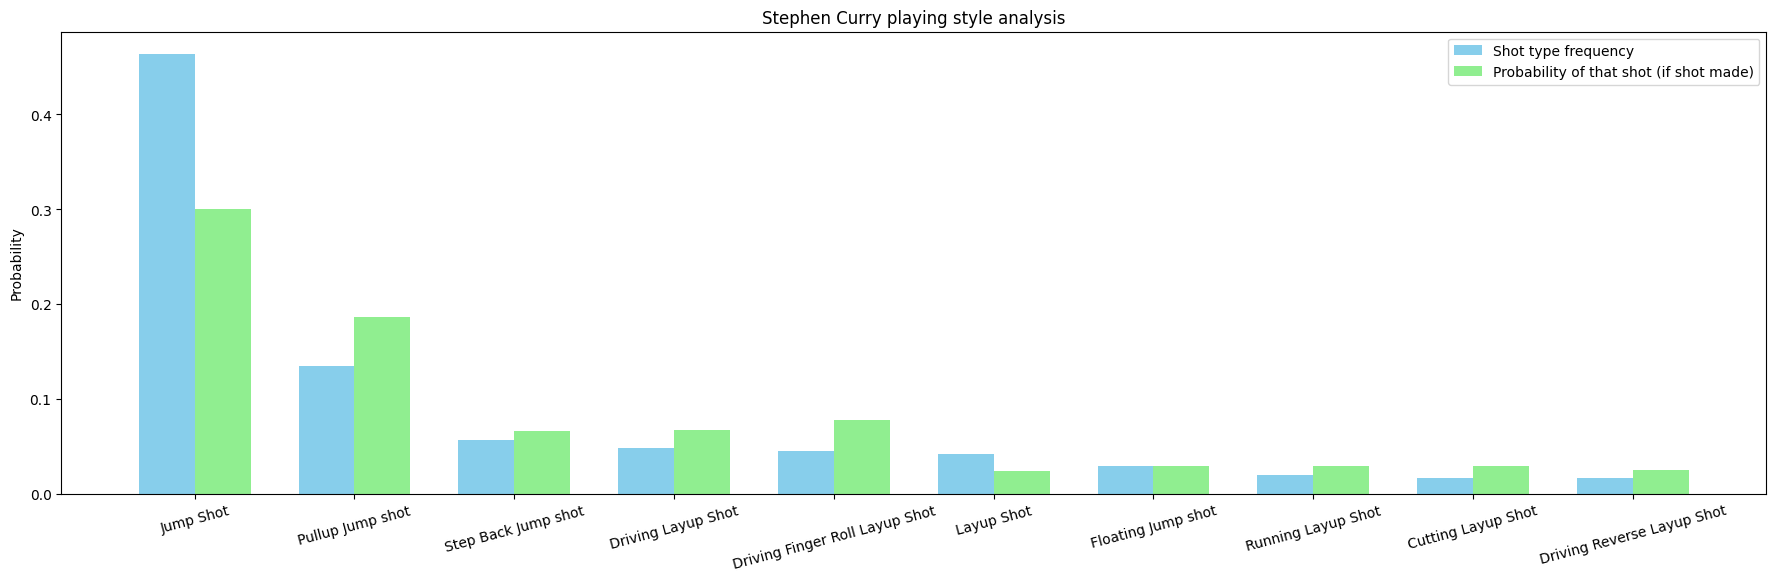

In [109]:
top_actions = shotsfiltered['ACTION_TYPE'].value_counts().nlargest(10).index.tolist()

df_top = shotsfiltered[shotsfiltered['ACTION_TYPE'].isin(top_actions)].copy()

shotmadeprob = shotsfiltered['SHOT_MADE'].mean()

print(f"{player} top 10 most used shot types:")
print(f"{top_actions}\n")
results = []

for action in top_actions:
    subset = shotsfiltered[shotsfiltered['ACTION_TYPE'] == action]
    
    shottypeprob = len(subset) / len(shotsfiltered) #how often that type of shot is chosen by the player?
    
    subshotmadeprob = subset['SHOT_MADE'].mean()
    
    probshotwasaction = (subshotmadeprob * shottypeprob) / shotmadeprob
    
    results.append({
        'Action': action,
        'Prior': shottypeprob,
        'Likelihood': subshotmadeprob,
        'Posterior': probshotwasaction
    })
    


df_res = pd.DataFrame(results).set_index('Action')

fig, ax = plt.subplots(figsize=(22, 6))
x = range(len(df_res))
width = 0.35

ax.bar([i - width/2 for i in x], df_res['Prior'], width, label='Shot type frequency', color='skyblue')
ax.bar([i + width/2 for i in x], df_res['Posterior'], width, label='Probability of that shot (if shot made)', color='lightgreen')

ax.set_ylabel('Probability')
ax.set_title(f'{player} playing style analysis')
ax.set_xticks(x)
ax.set_xticklabels(df_res.index, rotation=15)
ax.legend()

plt.show()

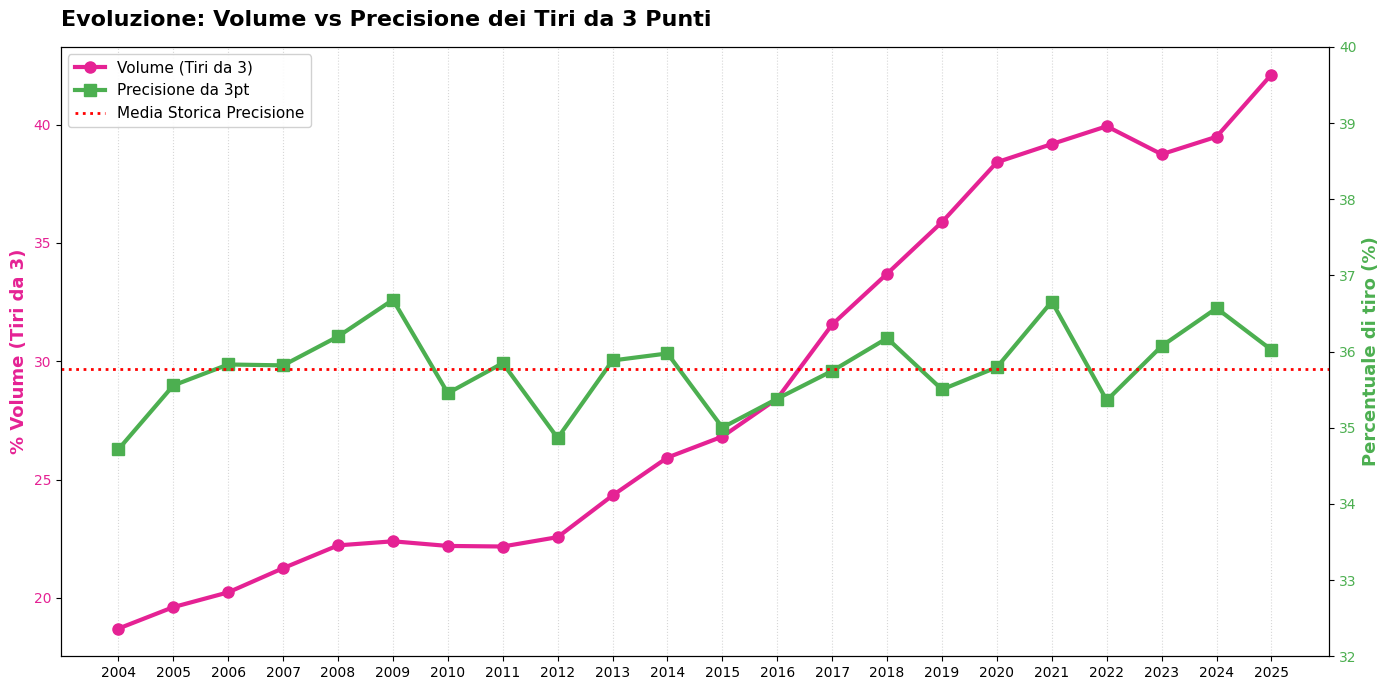

In [110]:
# Creiamo la figura di base
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- PRIMA LINEA: VOLUME (Asse Y Sinistro) ---
ax1.plot(years, perc_volume, marker='o', color="#e52294", linewidth=3, markersize=8, label="Volume (Tiri da 3)")


ax1.set_ylabel("% Volume (Tiri da 3)", fontsize=13, color="#e52294", fontweight='bold')
ax1.tick_params(axis='y', labelcolor="#e52294") # Colora i numeri dell'asse Y di rosa
ax1.set_xticks(years)
ax1.grid(axis='x', linestyle=':', alpha=0.5) # Griglia verticale per facilitare la lettura degli anni

# --- SECONDA LINEA: PRECISIONE (Asse Y Destro) ---
# Creiamo il secondo asse Y che condivide lo stesso asse X
ax2 = ax1.twinx()

ax2.plot(years, perc_precisione, marker='s', color='#4caf50', linewidth=3, markersize=8, label="Precisione da 3pt")

ax2.set_ylabel("Percentuale di tiro (%)", fontsize=13, color="#4caf50", fontweight='bold')
ax2.tick_params(axis='y', labelcolor="#4caf50") # Colora i numeri dell'asse Y destro di verde
ax2.set_ylim(32, 40) # Manteniamo il tuo limite per zoomare sulla precisione

# Aggiungiamo la media storica (legata all'asse della precisione)
media_storica = perc_precisione.mean()
ax2.axhline(media_storica, color='red', linestyle=':', linewidth=2, label=f'Media Storica Precisione')

# --- TITOLO E LEGENDA UNIFICATA ---
plt.title("Evoluzione: Volume vs Precisione dei Tiri da 3 Punti", fontsize=16, fontweight='bold', loc='left', pad=15)

# Per unire le due legende (visto che appartengono a due assi diversi)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

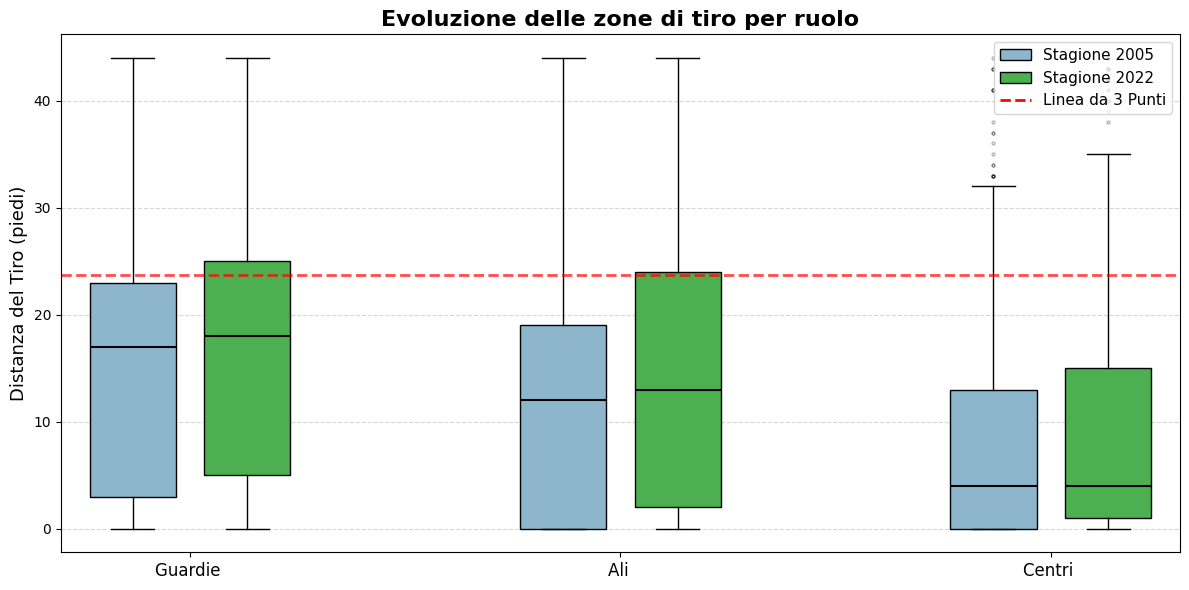

In [111]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

# 1. PARAMETRI INIZIALI
anno_passato = 2005
anno_recente = 2022
ordine_ruoli = ['G', 'F', 'C']
colore_passato = '#8db6cd'
colore_recente = '#4caf50'

# Filtriamo i dati generali
df_box = shots[shots['SEASON_1'].isin([anno_passato, anno_recente])].copy()
df_box = df_box.dropna(subset=['SHOT_DISTANCE', 'POSITION_GROUP'])

# --- NOVITÀ: FILTRO METÀ CAMPO (< 45 piedi) ---
# Eliminiamo i "preghieri" da fine quarto per avere statistiche pulite
df_box = df_box[df_box['SHOT_DISTANCE'] < 45]

# --- PREPARAZIONE DATI PER I DUE GRAFICI ---
dati_distanze = []
posizioni_box = []
colori_box = []
etichette_x = []

# Liste per il secondo grafico (Percentuali dal Campo Totali)
perc_totale_passato = []
perc_totale_recente = []

posizione_corrente = 1

for ruolo in ordine_ruoli:
    # -- DATI ANNO PASSATO --
    tiri_passato = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_passato)]
    dati_distanze.append(tiri_passato['SHOT_DISTANCE'].values)
    posizioni_box.append(posizione_corrente)
    colori_box.append(colore_passato)
    
    # Calcolo % Totale dal campo (Anno Passato)
    if len(tiri_passato) > 0:
        perc_totale_passato.append(tiri_passato['SHOT_MADE'].mean() * 100)
    else:
        perc_totale_passato.append(0)
    
    # -- DATI ANNO RECENTE --
    tiri_recente = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_recente)]
    dati_distanze.append(tiri_recente['SHOT_DISTANCE'].values)
    posizioni_box.append(posizione_corrente + 0.8)
    colori_box.append(colore_recente)
    
    # Calcolo % Totale dal campo (Anno Recente)
    if len(tiri_recente) > 0:
        perc_totale_recente.append(tiri_recente['SHOT_MADE'].mean() * 100)
    else:
        perc_totale_recente.append(0)
    
    # Etichette asse X
    etichette_x.append(posizione_corrente + 0.4)
    posizione_corrente += 3 


# ==========================================
# GRAFICO 1: BOXPLOT DELLE DISTANZE
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

bplot = ax1.boxplot(
    dati_distanze, positions=posizioni_box, widths=0.6,
    patch_artist=True, flierprops=dict(marker='o', color='black', markersize=2, alpha=0.3)
)


for patch, color in zip(bplot['boxes'], colori_box):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

ax1.axhline(23.75, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax1.set_xticks(etichette_x)
# Rimesse le etichette per renderlo leggibile da solo
ax1.set_xticklabels(['Guardie ', 'Ali ', 'Centri '], fontsize=12) 
ax1.set_title("Evoluzione delle zone di tiro per ruolo", fontsize=16, fontweight='bold')
ax1.set_ylabel("Distanza del Tiro (piedi)", fontsize=13)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

elementi_legenda = [
    Patch(facecolor=colore_passato, edgecolor='black', label=f'Stagione {anno_passato}'),
    Patch(facecolor=colore_recente, edgecolor='black', label=f'Stagione {anno_recente}'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Linea da 3 Punti')
]
ax1.legend(handles=elementi_legenda, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

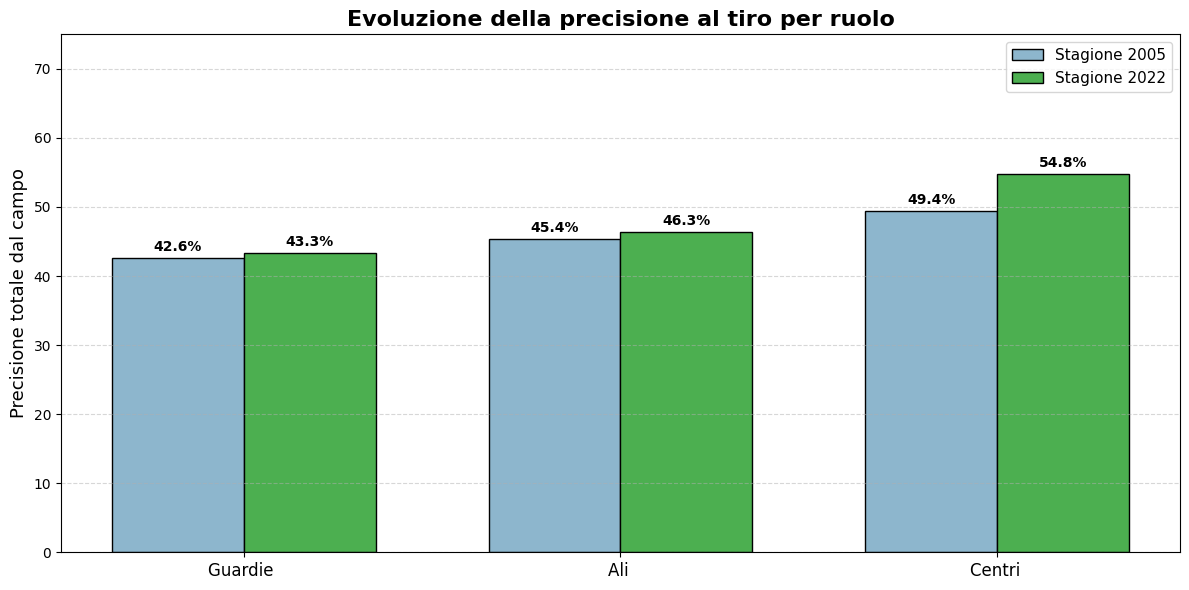

In [112]:
# ==========================================
# GRAFICO 2: BAR CHART PERCENTUALI TOTALI
# ==========================================
fig, ax2 = plt.subplots(figsize=(12, 6))

x_indici = np.arange(len(ordine_ruoli))
larghezza_barra = 0.35

barre1 = ax2.bar(x_indici - larghezza_barra/2, perc_totale_passato, larghezza_barra, color=colore_passato, edgecolor='black', label=f'Stagione {anno_passato}')
barre2 = ax2.bar(x_indici + larghezza_barra/2, perc_totale_recente, larghezza_barra, color=colore_recente, edgecolor='black', label=f'Stagione {anno_recente}')

def autolabel(barre):
    for rect in barre:
        altezza = rect.get_height()
        if altezza > 0:
            ax2.annotate(f'{altezza:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, altezza),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(barre1)
autolabel(barre2)

ax2.set_xticks(x_indici)
ax2.set_xticklabels(['Guardie ', 'Ali ', 'Centri '], fontsize=12)
ax2.set_ylabel("Precisione totale dal campo", fontsize=13)
ax2.set_title("Evoluzione della precisione al tiro per ruolo", fontsize=16, fontweight='bold')
ax2.set_ylim(0, 75) 
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Aggiunta legenda per il grafico singolo
ax2.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

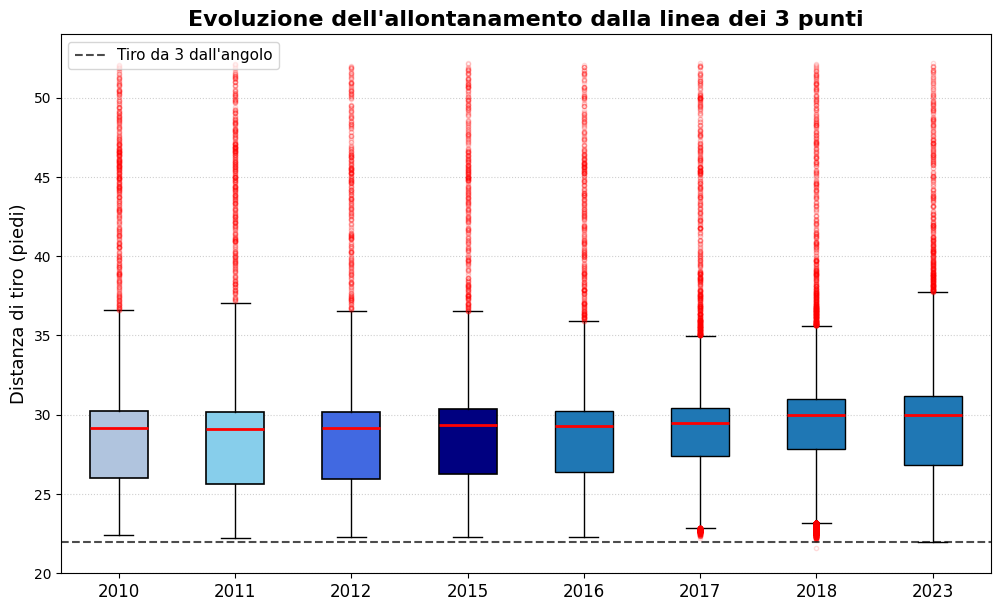

In [113]:
target_seasons = [2010, 2011, 2012,2015,2016, 2017, 2018, 2023]
dati_da_plottare = []

shots['EXACT_DISTANCE'] = np.sqrt(shots['LOC_X']**2 + shots['LOC_Y']**2) 

df_deep = shots[
    (shots['SHOT_TYPE'] == '3PT Field Goal') & 
    (shots['SEASON_1'].isin(target_seasons))
].copy()

for season in target_seasons:

    df_filtered = df_deep[(df_deep['SEASON_1'] == season) & 
                          (df_deep['SHOT_DISTANCE'] < 47) & 
                          (df_deep['SHOT_DISTANCE'] >1) & 
                          ~(df_deep['ACTION_TYPE'] == 'Right Corner 3') & 
                          ~(df_deep['ACTION_TYPE'] == 'Left Corner 3')]
    distanze = df_filtered['EXACT_DISTANCE'].values
        
    dati_da_plottare.append(distanze)

colori_scatole = ['#b0c4de', '#87ceeb', '#4169e1', '#000080'] 

fig, ax = plt.subplots(figsize=(12, 7))

bplot = ax.boxplot(
    dati_da_plottare,
    patch_artist=True,
    widths=0.5,
    flierprops=dict(marker='o', color='red', markeredgecolor='red', markersize=3, alpha=0.15)
)

for patch, color in zip(bplot['boxes'], colori_scatole):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

for median in bplot['medians']:
    median.set_color('red')
    median.set_linewidth(2)


ax.set_xticks(np.arange(1, len(target_seasons) + 1))
ax.set_xticklabels([f"{anno}" for anno in target_seasons], fontsize=12)

ax.set_title("Evoluzione dell'allontanamento dalla linea dei 3 punti", fontsize=16, fontweight='bold')
ax.set_ylabel("Distanza di tiro (piedi)", fontsize=13)

ax.axhline(22, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label="Tiro da 3 dall'angolo")

ax.set_ylim(20, 54)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

plt.show()

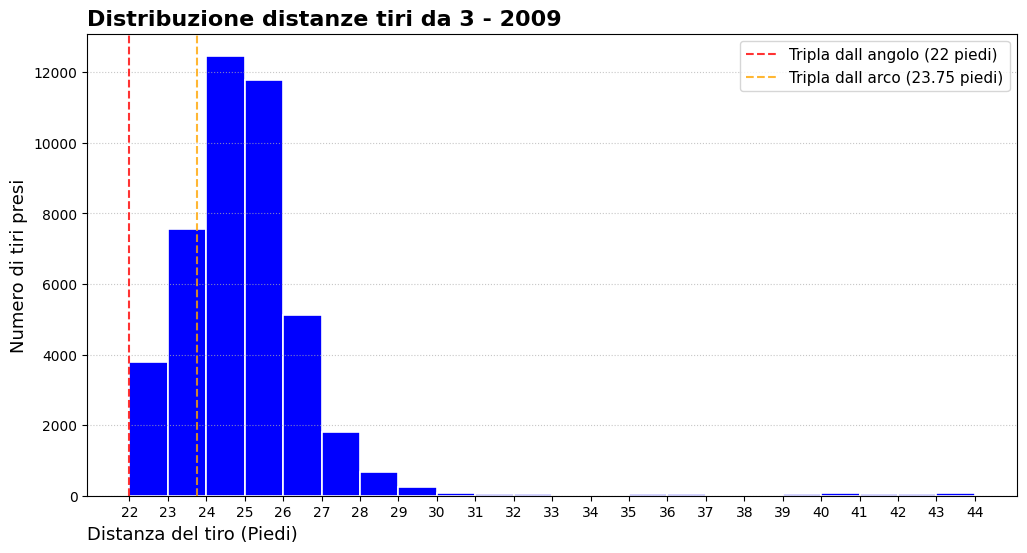

In [114]:
season = 2009

df = shots[
    (shots['SEASON_1'] == season) &
    (shots['SHOT_TYPE'] == '3PT Field Goal')
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['SHOT_DISTANCE'], bins=range(22, 45), color='blue', edgecolor='white', linewidth=1.2)

ax.set_title(f"Distribuzione distanze tiri da 3 - {season}", fontsize=16, fontweight='bold', loc="left")
ax.set_xlabel("Distanza del tiro (Piedi)", fontsize=13, loc="left")
ax.set_ylabel("Numero di tiri presi", fontsize=13)

ax.axvline(22.0, color='red', linestyle='--', alpha=0.8, label='Tripla dall angolo (22 piedi)')
ax.axvline(23.75, color='orange', linestyle='--', alpha=0.8, label='Tripla dall arco (23.75 piedi)')

ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_xticks(range(22, 45))
ax.legend(loc='upper right', fontsize=11)

plt.show()

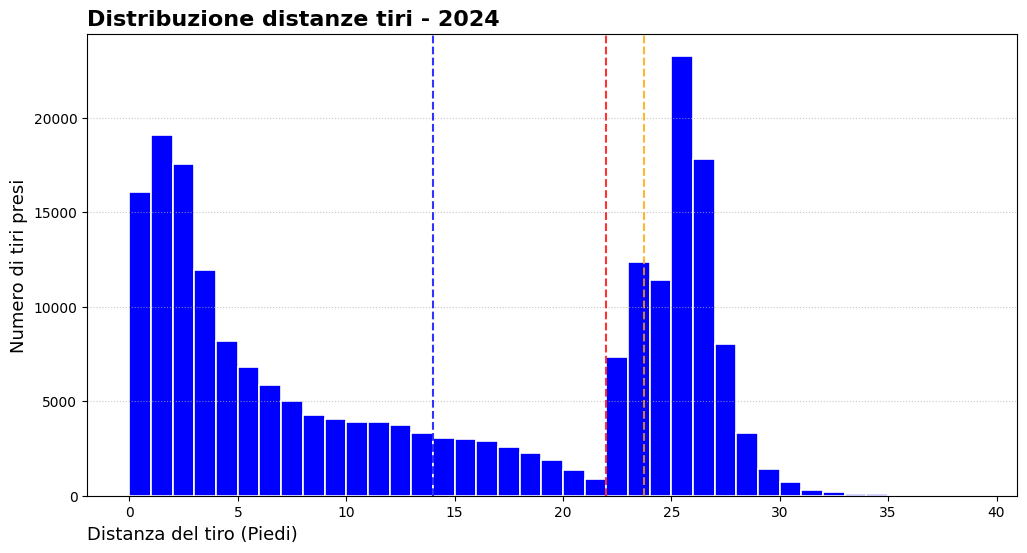

In [115]:
season = 2024

df = shots[
    (shots['SEASON_1'] == season) 
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['SHOT_DISTANCE'], bins=range(0,40), color='blue', edgecolor='white', linewidth=1.2)

ax.set_title(f"Distribuzione distanze tiri - {season}", fontsize=16, fontweight='bold', loc="left")
ax.set_xlabel("Distanza del tiro (Piedi)", fontsize=13, loc="left")
ax.set_ylabel("Numero di tiri presi", fontsize=13)

ax.axvline(22.0, color='red', linestyle='--', alpha=0.8, label='Tripla dall angolo (22 piedi)')
ax.axvline(23.75, color='orange', linestyle='--', alpha=0.8, label='Tripla dall arco (23.75 piedi)')
ax.axvline(14, color='blue', linestyle='--', alpha=0.8, label='Area del midrange (dai 14 piedi)')

ax.grid(axis='y', linestyle=':', alpha=0.7)
#ax.legend(loc='upper right', fontsize=11)

plt.show()

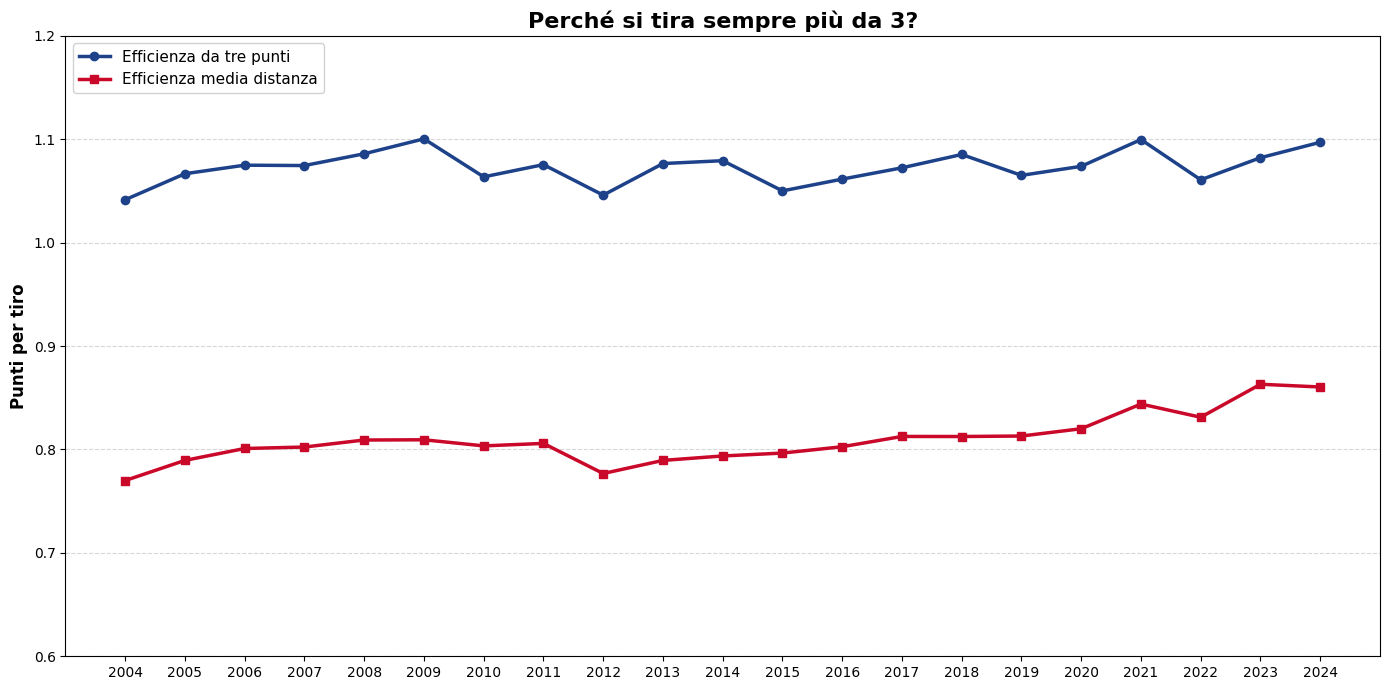

In [126]:
anni_analisi = range(2004, 2025)
df_eff = shots[(shots['SEASON_1'].isin(anni_analisi))].copy()

df_eff['IS_MADE'] = np.where(df_eff['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']), 1, 0)

df_eff['PT_VALUE'] = np.where(df_eff['SHOT_TYPE'] == '3PT Field Goal', 3, 2)
df_eff['POINTS_EARNED'] = df_eff['IS_MADE'] * df_eff['PT_VALUE']

condizioni = [
    df_eff['SHOT_TYPE'] == '3PT Field Goal',
    (df_eff['SHOT_TYPE'] != '3PT Field Goal') & (df_eff['SHOT_DISTANCE'] > 10), # Mid-range (inefficiente)
    (df_eff['SHOT_TYPE'] != '3PT Field Goal') & (df_eff['SHOT_DISTANCE'] <= 10) # Area pitturata (efficiente)
]
scelte = ['3PT', 'Mid-Range', 'Paint']
df_eff['ZONE'] = np.select(condizioni, scelte, default='Unknown')

efficienza = df_eff.groupby(['SEASON_1', 'ZONE'])['POINTS_EARNED'].mean().unstack()

volume = df_eff.groupby(['SEASON_1', 'ZONE']).size().unstack()
volume['Total'] = volume.sum(axis=1)
volume['3PT_Pct'] = (volume['3PT'] / volume['Total']) * 100

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(efficienza.index, efficienza['3PT'], color='#1d428a', marker='o', linewidth=2.5, label='Efficienza da tre punti')
ax1.plot(efficienza.index, efficienza['Mid-Range'], color='#c9082a', marker='s', linewidth=2.5, label='Efficienza media distanza')

ax1.set_ylabel('Punti per tiro', fontsize=12, fontweight='bold', color='black')
ax1.set_ylim(0.6, 1.2) 
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Titoli e legende
plt.title('Perché si tira sempre più da 3?', fontsize=16, fontweight='bold')

# Combiniamo le legende dei due assi
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, framealpha=0.9)

# Assicuriamoci che tutte le stagioni siano visibili sull'asse X
ax1.set_xticks(anni_analisi)


plt.tight_layout()
plt.show()

fare le percentuali di riuscita tiro in base alla distanza per capire se effettivamente rimane conveniente tirare da lontano o dopo una certa distanza a sto punto conviene tirare da più vicino o altrimenti da due punti

premessa sul fatto che rappresenti solo alcuni anni
Evoluzione dei tiri da 3 punti, è cambiato il trend? si tira in modo diverso? si tira da più lontano? se sì, perché?
esposizioni:
-grafico del campo con i tiri di un giocatore di un anno e di un altro (2005, 2017)
-stesso grafico ma a barre con la distribuzione dei tiri (evidenzia che non è una normale)
-distribuzione dei tiri da 3 (e avvicinamento alla normale), fatti la domanda "come mai si allontanano di più dal canestro per fare tiri che valgono sempre 3?"
-evoluzione di percentuale di tiri da 3 sul totale dei tiri presi con evoluzione percentuali
-controllo confrontando con tiri dalla media se l'efficienza rimane positiva (tipo se dalla media tiri al 50% da 3 devi tirare al 33% almeno per fare più punti per tiro) e vedi quali stagioni sono con efficienza positiva
-le percentuali di riuscita tiri sono però rimaste uguali nella lega, il segreto è nel fatto che più giocatori hanno iniziato a tirare da 3 punti con percentuali più alte (le guardie hanno la stessa percentuale ma tirano da casa loro e altri ruoli hanno iniziato a tirare dalle stesse distanze)
-analisi nei quarti e conferma del fatto che si è molto più efficienti senza stanchezza (fai un check eliminando i tiri che sono negli ultimi 3 secondi)
-



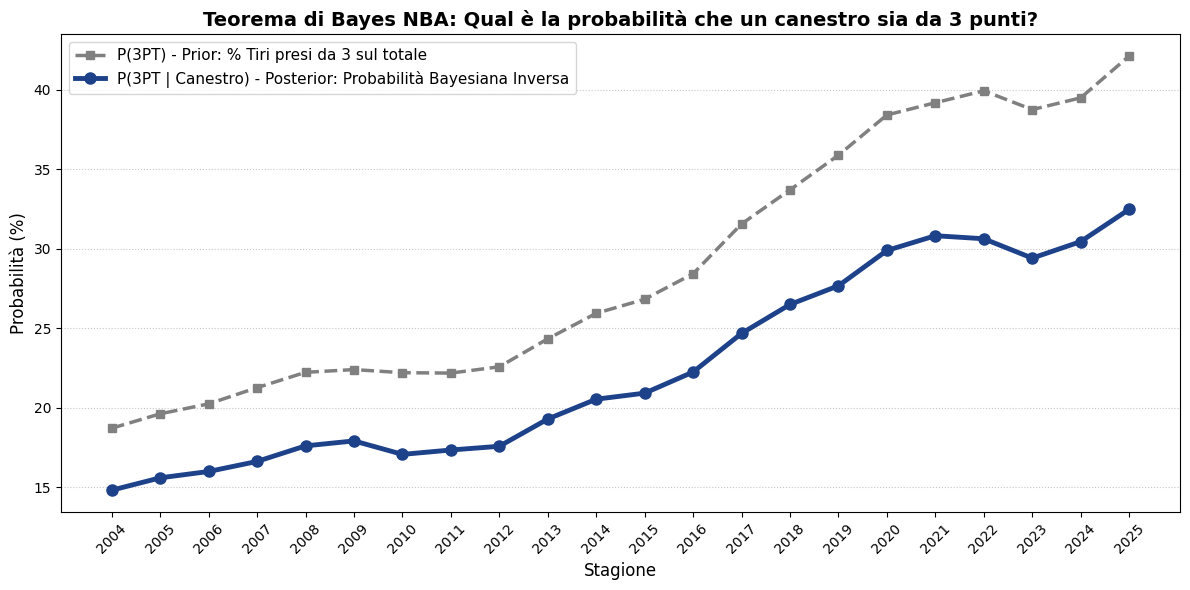

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepariamo i dati partendo dal dataset completo
df_bayes = shots.copy()

# Uniformiamo la colonna dei canestri (1 se segnato, 0 se sbagliato)
df_bayes['IS_MADE'] = np.where(df_bayes['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']), 1, 0)

# Creiamo le variabili per identificare i tiri da 3 punti e i tiri da 3 segnati
df_bayes['IS_3PT'] = np.where(df_bayes['SHOT_TYPE'] == '3PT Field Goal', 1, 0)
df_bayes['3PT_MADE'] = np.where((df_bayes['IS_3PT'] == 1) & (df_bayes['IS_MADE'] == 1), 1, 0)

# 2. Calcoliamo i totali aggregati per ogni singola stagione
bayes_stats = df_bayes.groupby('SEASON_1').agg(
    Total_Att=('IS_MADE', 'count'),       # Totale tiri tentati (tutti)
    Total_Made=('IS_MADE', 'sum'),        # Totale tiri segnati (tutti)
    Att_3PT=('IS_3PT', 'sum'),            # Totale tiri da 3 tentati
    Made_3PT=('3PT_MADE', 'sum')          # Totale tiri da 3 segnati
).reset_index()

# --- 3. IL TEOREMA DI BAYES (La Matematica) ---

# P(3PT) = Prior: Probabilità a priori che un tiro preso sia da 3
bayes_stats['P_3PT'] = bayes_stats['Att_3PT'] / bayes_stats['Total_Att']

# P(Canestro | 3PT) = Likelihood: Probabilità di segnare sapendo che il tiro è da 3 (FG% da 3)
bayes_stats['P_Made_given_3PT'] = bayes_stats['Made_3PT'] / bayes_stats['Att_3PT']

# P(Canestro) = Marginal: Probabilità globale di segnare un tiro qualsiasi (FG% globale)
bayes_stats['P_Made'] = bayes_stats['Total_Made'] / bayes_stats['Total_Att']

# P(3PT | Canestro) = Posterior: LA FORMULA DI BAYES
bayes_stats['P_3PT_given_Made'] = (bayes_stats['P_Made_given_3PT'] * bayes_stats['P_3PT']) / bayes_stats['P_Made']

# --- 4. CREAZIONE DEL GRAFICO ---
fig, ax = plt.subplots(figsize=(12, 6))

# Linea del Prior P(3PT)
ax.plot(bayes_stats['SEASON_1'], bayes_stats['P_3PT'] * 100, 
        color='gray', linestyle='--', linewidth=2.5, marker='s', markersize=6,
        label='P(3PT) - Prior: % Tiri presi da 3 sul totale')

# Linea del Posterior P(3PT | Canestro)
ax.plot(bayes_stats['SEASON_1'], bayes_stats['P_3PT_given_Made'] * 100, 
        color='#1d428a', linewidth=3.5, marker='o', markersize=8, 
        label='P(3PT | Canestro) - Posterior: Probabilità Bayesiana Inversa')

# Estetica e formattazione
ax.set_title("Teorema di Bayes NBA: Qual è la probabilità che un canestro sia da 3 punti?", 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Stagione', fontsize=12)
ax.set_ylabel('Probabilità (%)', fontsize=12)

# Griglia e assi
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_xticks(bayes_stats['SEASON_1'])
plt.xticks(rotation=45)

# Legenda
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

esiste un giocatore che spicca rispetto agli altri in una stagione per stile di gioco/tipologia di tiri presi?
quanto è cambiato lo stile di gioco dei giocatori negli years?

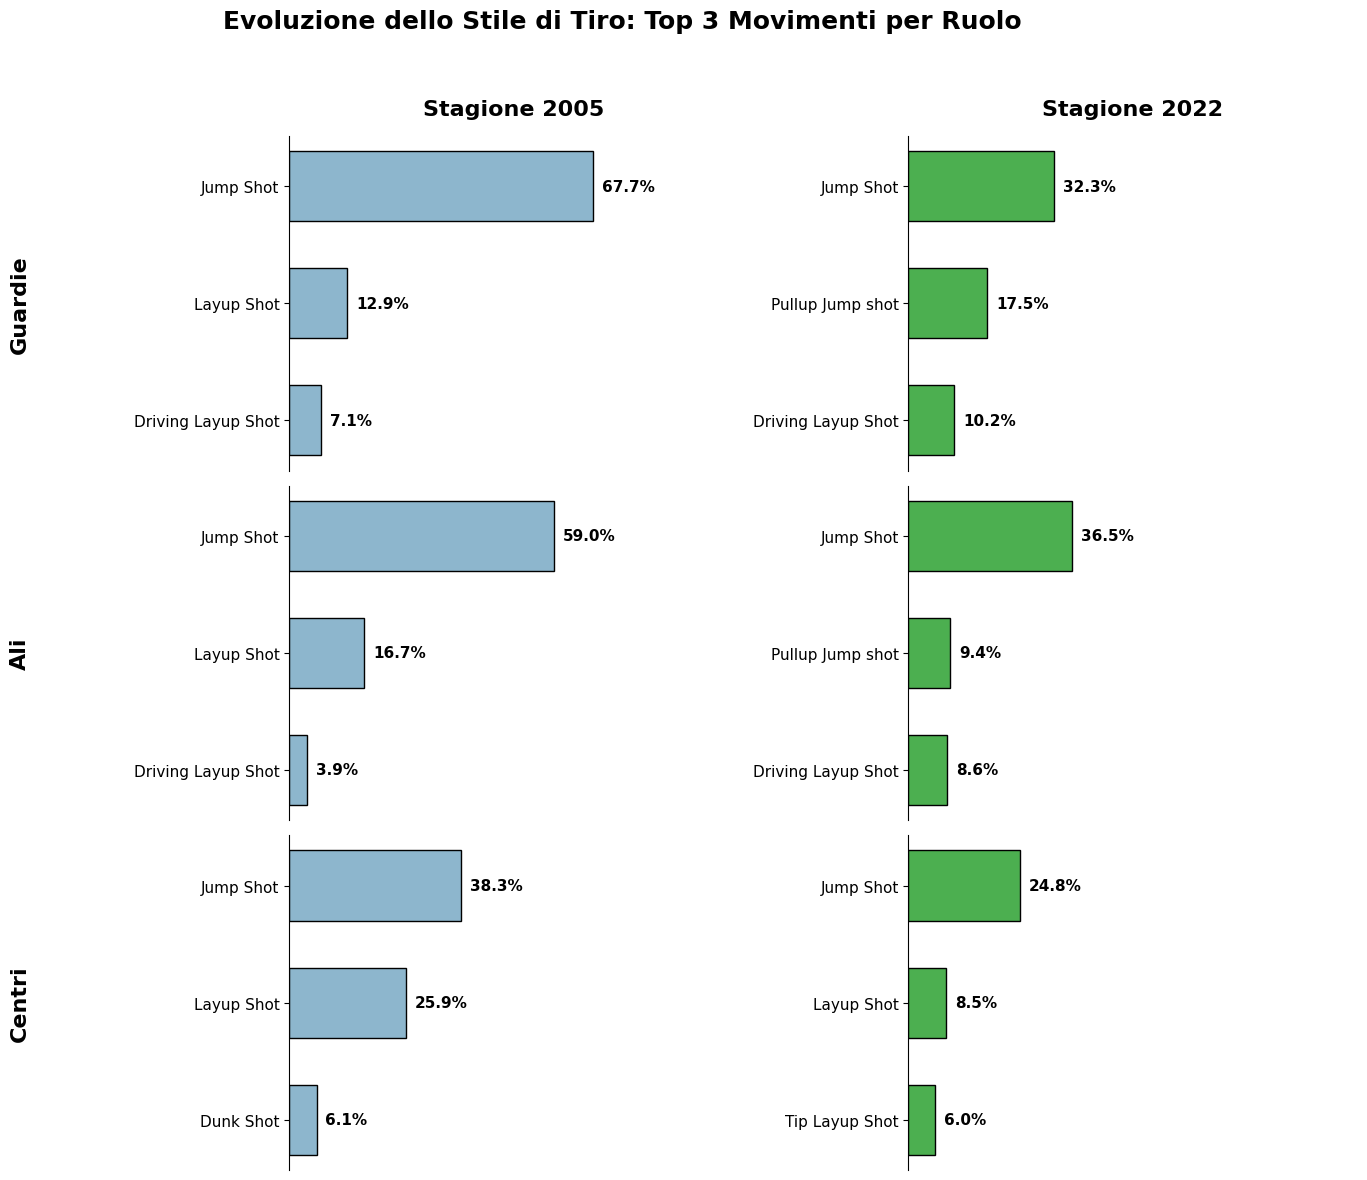

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. PARAMETRI INIZIALI
anno_passato = 2005
anno_recente = 2022
ordine_ruoli = ['G', 'F', 'C']
nomi_ruoli = {'G': 'Guardie', 'F': 'Ali', 'C': 'Centri'}

# Filtriamo i dati rimuovendo le righe senza tipologia di tiro
df_style = shots[shots['SEASON_1'].isin([anno_passato, anno_recente])].copy()
df_style = df_style.dropna(subset=['ACTION_TYPE', 'POSITION_GROUP'])

# 2. CREAZIONE DELLA GRIGLIA DI GRAFICI (3 righe, 2 colonne)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle("Evoluzione dello Stile di Tiro: Top 3 Movimenti per Ruolo", fontsize=18, fontweight='bold')

# 3. CICLO SUI RUOLI E SUGLI ANNI
for i, ruolo in enumerate(ordine_ruoli):
    for j, anno in enumerate([anno_passato, anno_recente]):
        ax = axes[i, j] # Selezioniamo il singolo "quadratino" della griglia
        
        # Filtriamo i dati per quel ruolo e quell'anno specifico
        subset = df_style[(df_style['POSITION_GROUP'] == ruolo) & (df_style['SEASON_1'] == anno)]
        
        if len(subset) > 0:
            # Calcoliamo la percentuale di utilizzo di ogni movimento
            frequenze = subset['ACTION_TYPE'].value_counts(normalize=True) * 100
            
            # Prendiamo solo i primi 3
            top_3 = frequenze.head(3)
            
            # Invertiamo l'ordine per avere il tiro più usato in alto nel grafico
            y_pos = np.arange(len(top_3))
            valori = top_3.values[::-1]
            etichette = top_3.index[::-1]
            
            # Impostiamo i colori (Azzurro per 2005, Verde per 2022)
            colore = '#8db6cd' if anno == anno_passato else '#4caf50'
            
            # Disegniamo il grafico a barre orizzontali (barh)
            bars = ax.barh(y_pos, valori, color=colore, edgecolor='black', height=0.6)
            
            # Sistemiamo le etichette sull'asse Y (I nomi dei tiri)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(etichette, fontsize=11)
            
            # Aggiungiamo la percentuale scritta di fianco a ogni barra
            for bar in bars:
                width = bar.get_width()
                ax.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                        ha='left', va='center', fontweight='bold', fontsize=11)
        
        # 4. FORMATTAZIONE ESTETICA DEL QUADRATINO
        ax.set_xlim(0, 100) # Fissiamo l'asse X a 100% per tutti, per avere un confronto visivo reale
        ax.set_xticks([])   # Nascondiamo i numeri sotto, abbiamo già le etichette sulle barre
        
        # Rimuoviamo i bordi neri inutili (Despining) per un look più pulito
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        
        # Titoli delle colonne (Solo sulla prima riga)
        if i == 0:
            ax.set_title(f"Stagione {anno}", fontsize=16, fontweight='bold', pad=15)
            
        # Titoli delle righe (Solo sulla prima colonna)
        if j == 0:
            # text(x, y, stringa) -> lo posizioniamo fuori dal grafico a sinistra
            ax.text(-0.6, 0.5, nomi_ruoli[ruolo], transform=ax.transAxes, 
                    fontsize=16, fontweight='bold', rotation=90, va='center', ha='center')

# Aggiustiamo gli spazi per non far sovrapporre i testi
plt.tight_layout(rect=[0.05, 0, 1, 0.95])
plt.show()

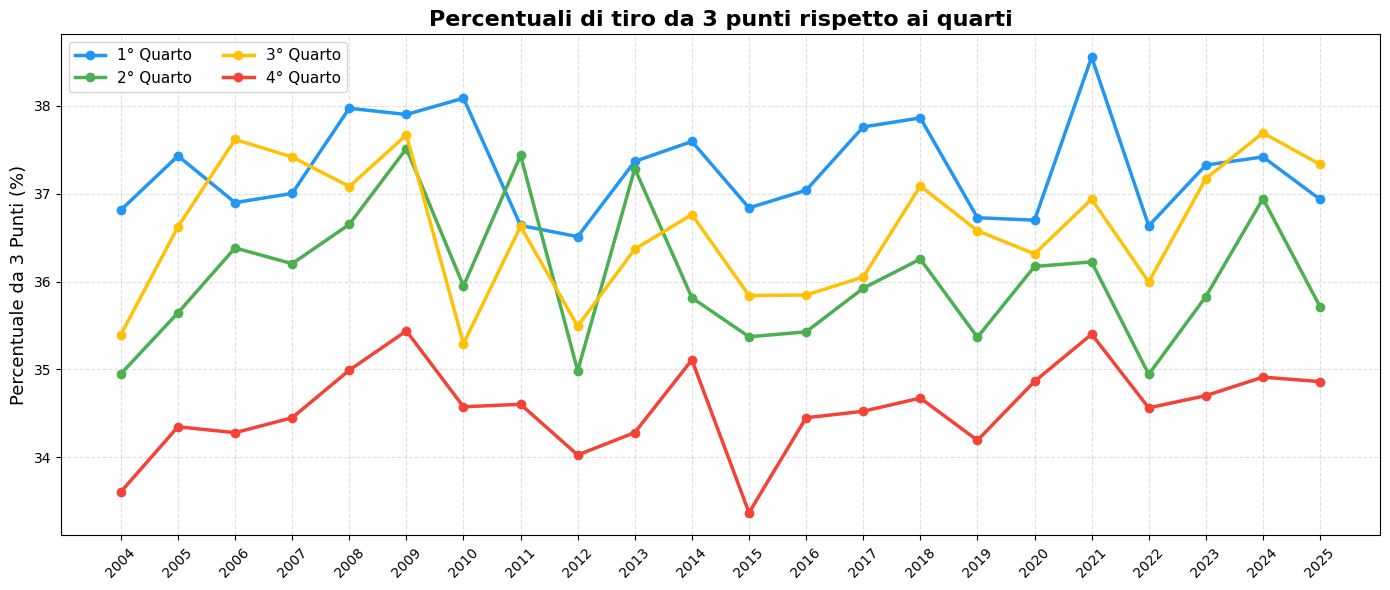

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARAZIONE DEI DATI
# Filtriamo i quarti regolamentari E teniamo SOLO i tiri da 3 punti
df_fatigue_3pt = shots[
    (shots['QUARTER'].isin([1, 2, 3, 4])) & 
    (shots['SHOT_TYPE'] == '3PT Field Goal')
].copy()

# Manteniamo la pulizia rimuovendo i "preghieri" oltre metà campo
df_fatigue_3pt = df_fatigue_3pt[df_fatigue_3pt['SHOT_DISTANCE'] < 45]

# 2. AGGREGAZIONE DATI PER STAGIONE E QUARTO
# Calcoliamo la % di triple segnate e la distanza media
fatigue_stats_3pt = df_fatigue_3pt.groupby(['SEASON_1', 'QUARTER']).agg(
    FG3_PCT=('SHOT_MADE', lambda x: x.mean() * 100),
    AVG_DIST=('SHOT_DISTANCE', 'mean')
).reset_index()

# Creiamo le tabelle pivot per facilitare il plot
fg3_pivot = fatigue_stats_3pt.pivot(index='SEASON_1', columns='QUARTER', values='FG3_PCT')
dist3_pivot = fatigue_stats_3pt.pivot(index='SEASON_1', columns='QUARTER', values='AVG_DIST')
years_3pt = fg3_pivot.index

# Colori progressivi (Freddo = Fresco, Caldo = Stanco)
colori_quarti = {1: '#2196F3', 2: '#4CAF50', 3: '#FFC107', 4: '#F44336'}
labels_quarti = {1: '1° Quarto', 2: '2° Quarto', 3: '3° Quarto', 4: '4° Quarto'}

# ==========================================
# GRAFICO 1: EFFICIENZA DA 3 PUNTI (3P%)
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 6))

for q in [1, 2, 3, 4]:
    ax1.plot(years_3pt, fg3_pivot[q], marker='o', markersize=6, linewidth=2.5, 
             color=colori_quarti[q], label=labels_quarti[q])

#ax1.set_xlabel("Stagione NBA", fontsize=13)
ax1.set_ylabel("Percentuale da 3 Punti (%)", fontsize=13)
ax1.set_title("Percentuali di tiro da 3 punti rispetto ai quarti", fontsize=16, fontweight='bold')
ax1.grid(axis='both', linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=11, ncol=2)

ax1.set_xticks(years_3pt)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()